# $k$-Neraest Neighbors

In [1]:
from IPython.display import Image

$$P(Y = j \mid X = x_0) = \frac{1}{k} \sum_{i \in N_0} I(y_i = j)\text{,}$$
$$I=\text{indicator function, } N_0 = \text{ set of } k \text{ points}$$

- Instead of Bayesian classifiers that use _unified probability_ for assigning classes, $k$-NN uses _local probabilities_. 
  - $k$-NN approximates the conditional probability for a given class with the _fraction_ of observations in local neighborhood of $k$ observations that correspond to the class.
- $k$-NN is a memory based algorithm, so no training is required.
  - $k$-NN does **not** learn any parameters during training phase; it simply stores the entire training dataset in memory. 
  - Unlike neural network or logistic regression, which takes training data and distills it into weights (parameters). Once a model is trained here, we do not need the original data anymore.
  - Everything is done at the time of prediction, so no model is needed.
- Especially **sensitive** to variable scaling and standardization.
- Has **nonlinear** decision boundaries. 
  - We do not have to explicitly define what the boundary looks like. 
  - Since it votes locally, the boundary naturally bends and curves to follow the actual data structure. 

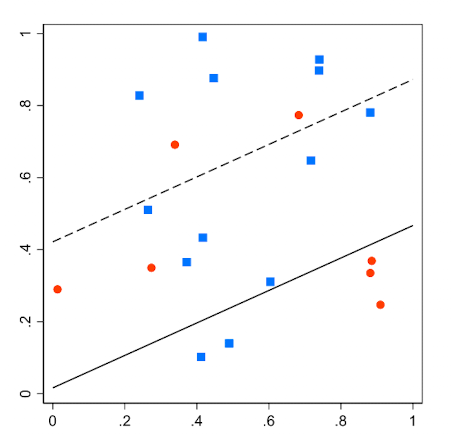

In [2]:
Image("../data/kNN/linear-boundary.png")

- This is a **linear boundary** formed by logistic regression; a straight, linear line should seperate data into classes.

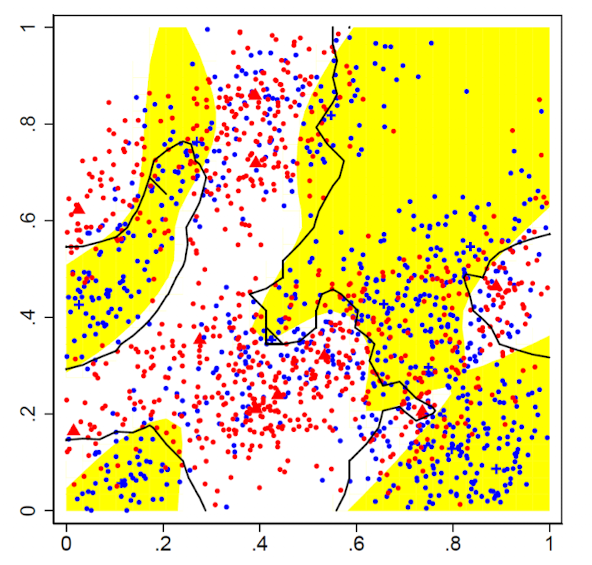

In [3]:
Image("../data/kNN/nonlinear-boundary.png")

- - From above, <span style="color:yellow">yellow lines</span> represent the Bayes classifier, and **black** lines represent $k$-NN boundaries with ($k=50$).

## Bias vs. Variance
- Since $k$-NN relies on nearest neighbors to make predictions, $1$-NN has **low bias** but **high variance**.
  - Conditional probabilities for class assignments are made too locally.
- Increasing $k$ makes the estimate to be more stable (**reduce variance**.)
- Increasing $k$ also increases the average distance of $k$ training observations to the new point, $x_0$ (**increasing bias**).

## Exceptions
- There can be **exceptions** as when there is a _tie_ between neighboring votes.
- To resolve this:
  - Break ties at random.
  - Increase $k$ until tie is broken.
  - Use $1$-NN as a tie breaker (Use the single closest observation.)

## Hyperparameter Tuning
### Choice of $k$
- $k$=1 will be very unstable with lots of noise. 
- It is better to choose **odd** number of $k$ to reduce the chance of ties.
- Choose $k$ that yields the smllest error on the test data.

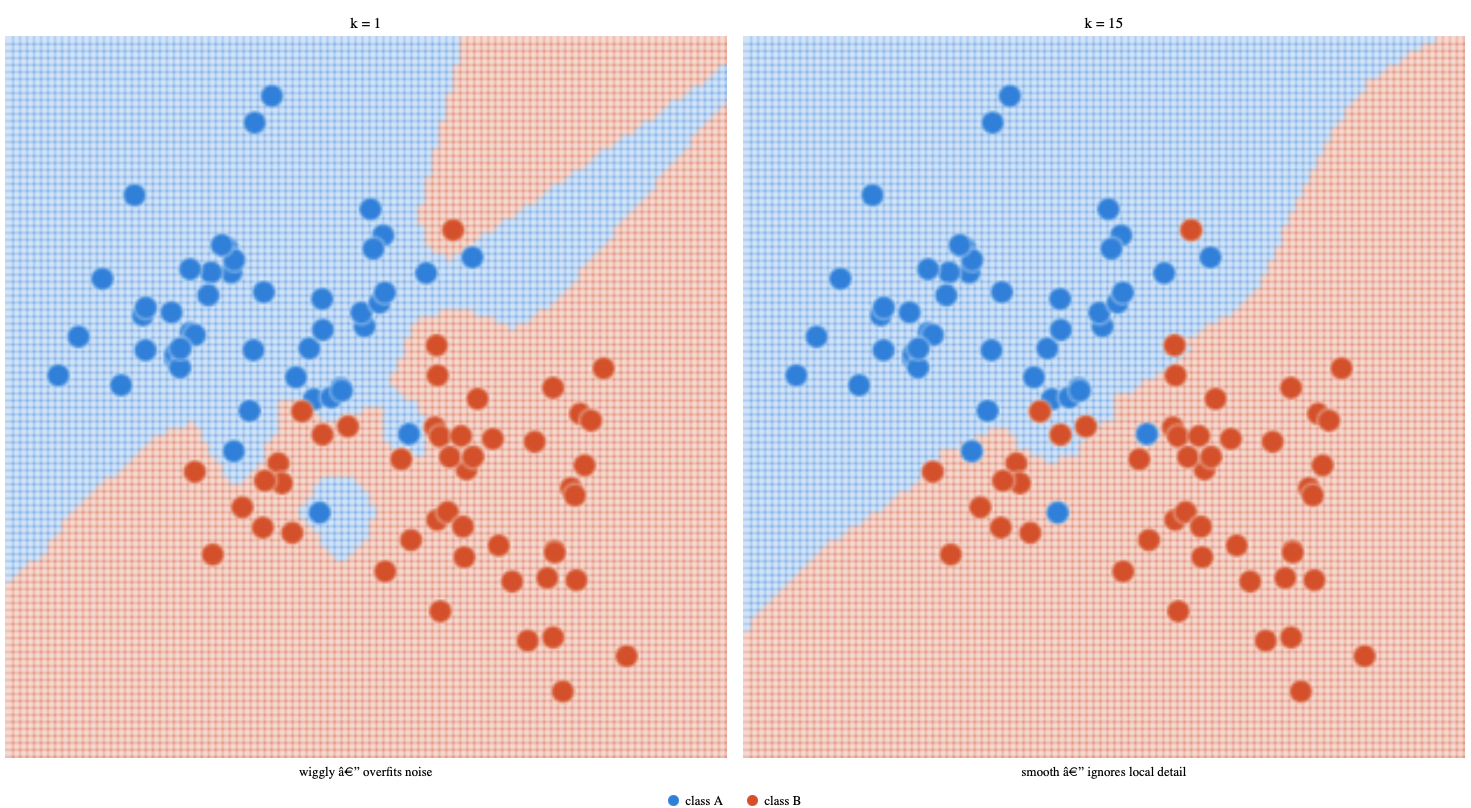

In [5]:
Image("../data/kNN/decision-boundary2.png")

- Small $k$ makes decision boundaries to be very wiggly and twisted. It contorts around every single point, including small clusters of _outlier_ points mixed into the wrong region. Leads to low bias but high variance.
- Large $k$ makes smoother boundary, and largely ignores _outlier_ clusters. They find the overall trend instead. Leads to low variance but higher bias.

## Distance 
- How are **distance** among observations calculated?
- Commonly Euclidean distance is used, but there are other metrics. 

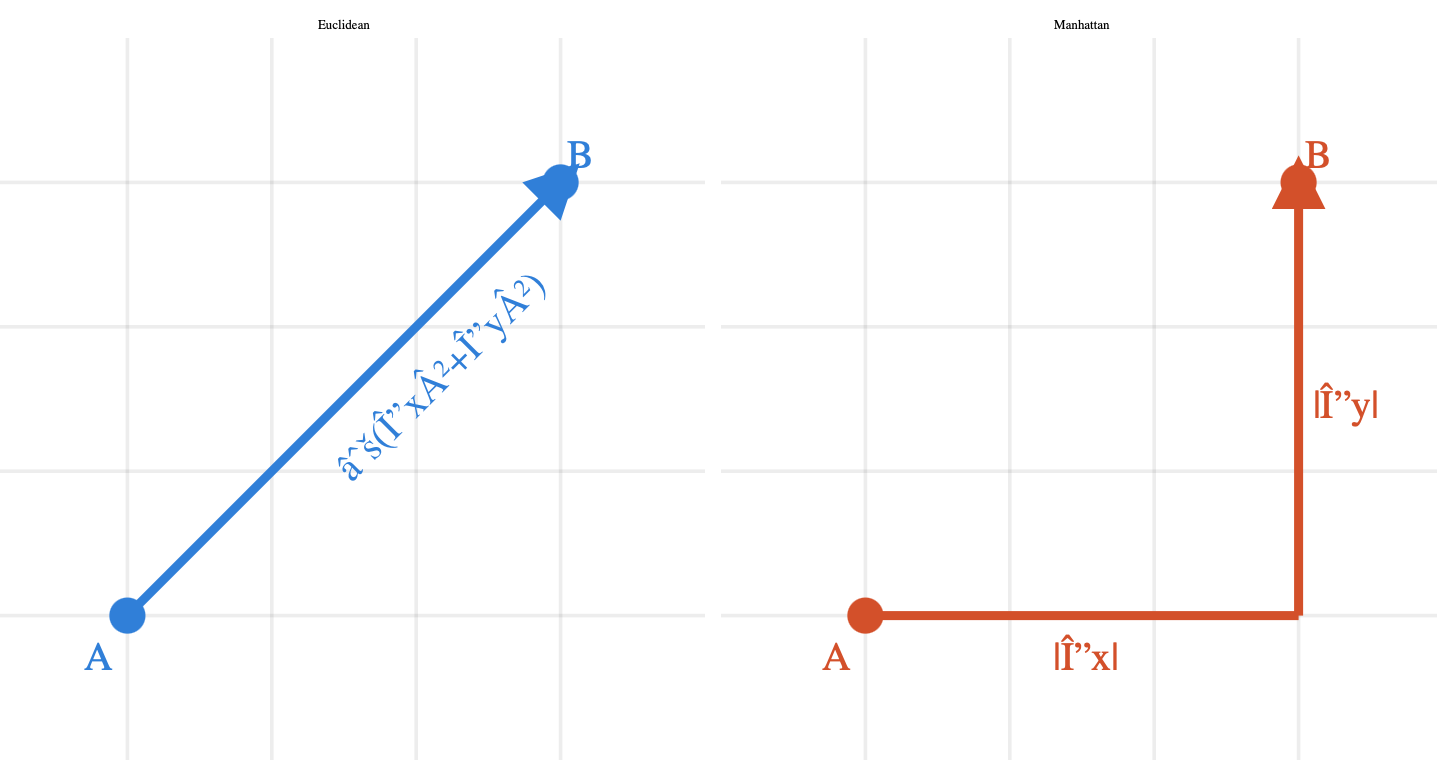

In [6]:
Image("../data/kNN/distances.png")

### Euclidean Distance
- For two points, $(x_1, y_1)$ and $(x_2, y_2)$,
$$\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}$$
- Penalizes large differences in any angle dimension heavily. 
- Flying in a _straight line_, cutting diagonally through buildings as an analogy. 
- Useful when:
  - Features are continuous and on similar scales.
  - When we expect diagonal relationships between data. 
  - Low to medium dimensionality.
    - Becomes meaningless in high-dimensional data due to the curse of dimensionality, because every point becomes equidistant. 

### Manhattan Distance
- For two points, $(x_1, y_1)$ and $(x_2, y_2)$,
$$|x_2-x_1| + |y_2-y_1|$$
- Also called as the **L1**.
- Treats each dimension equally and adds up the absolute gap.
- Walk along the grid, only moving horizontally or vertically as an analogy.
- Useful when:
  - Features are on very different scales.
  - High-dimensional data. 
  - Sparse data (like TF-IDF vectors), where most dimensions are zero. 
  - Want outliers in one dimension to have less outsized influence. 

### Similarity
- Instead of distance metrics, **similarity metric** can also be used.
- Any distance metric can be turned into a similarity metric, vice versa.
  - Smallest distance goes with greatest similarity.
$$s(x_0,x_1) = 1-\frac{d(x_0, x_1)}{d_{\text{max}}}\text{,}$$
$$d_{\text{max}} = \text{ the largest distance observed in data}$$
- **Cosine similarity** is often used in text mining and document retrieval, because the $X$-matrix is very sparse.

## Derivations
### Nearest Neighbor with Caliper
- Used for sparse data where nearest $k$ observations may be far away.
- Isntead of specifying a fixed number of $k$ neighbors, one can use all observations in a caliper (fixed distance) around a new observation.
- Could be risky if there are no observations in a given caliper leading to missing values. 

## Usage
- Useful when classification boundary is highly irregular, with nonlinear relationships.
  - When we have no assumption about data shape.
- Small to medium datasets.
  - $k$-NN stores all data and compares at prediction time. Could be slow for large datasets.
- Low-dimensional data. 

## Limitations
- Not useful for high dimentional data due to _curse of dimensionality_ and distances become meaningless.
- Large datasets due to slow predictions.
- Irrelevant features, when distance gets distorted. 
- Features with different scales.
- Difficult to explain, hard interpretability. 

::::{grid} 2
:::{grid-item}
:class: text-center
{button}`School Notes <../school-notes/Texts.pdf>`
:::
:::{grid-item}
:class: text-center
{button}`Solutions Key <../solution/kNN.pdf>`
:::
::::